In [1]:

from pathlib import Path
from datetime import datetime

from matplotlib import pyplot as plt
import numpy as np
import pydicom
from scipy import ndimage

from pylinac.core.image_generator import AS1200Image, AS1000Image
import pylinac.core.image_generator.layers as layers

In [3]:
def generate_dicom(file_out_name, layers):
    as1200 = AS1200Image()
    for layer in layers:
        as1200.add_layer(layer)
    as1200.generate_dicom(file_out_name=file_out_name, gantry_angle=0)
    return as1200.image

In [4]:
dir_path = Path(".")
dir_path = dir_path / "Flatness"
dir_path.mkdir(parents=True, exist_ok=True)

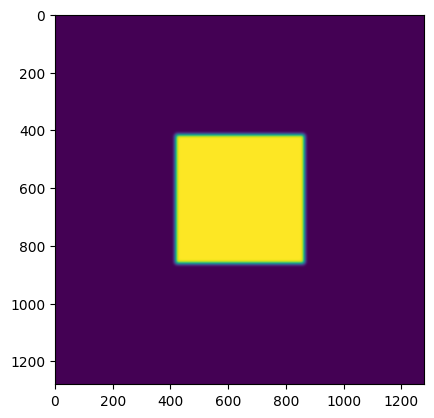

In [5]:
perfect_open_field_layers = [
    layers.PerfectFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_perfect_10x10.dcm"
as1200 = generate_dicom(file_path, perfect_open_field_layers)
plt.imshow(as1200)

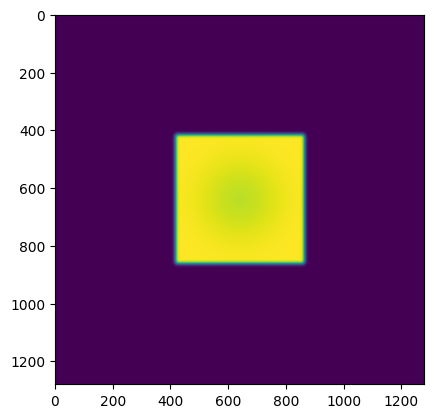

In [9]:
field_layers = [
    layers.FilteredFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    gaussian_height=0.1, 
    gaussian_sigma_mm=32.0,
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_excess_horns_10x10.dcm"
as1200 = generate_dicom(file_path, field_layers)
plt.imshow(as1200)

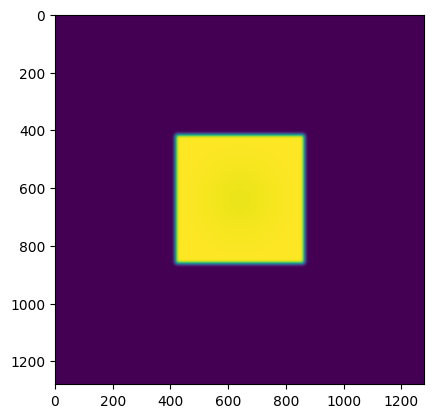

In [ ]:
field_layers = [
    layers.FilteredFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    gaussian_height=0.03, 
    gaussian_sigma_mm=32.0,
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_filtered_10x10.dcm"
as1200 = generate_dicom(file_path, field_layers)
plt.imshow(as1200)

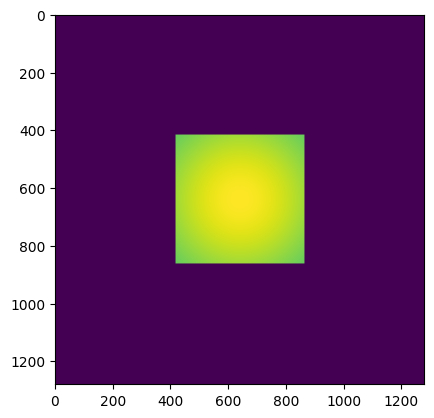

In [ ]:
field_layers = [
    layers.FilterFreeFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_imperfect_fff_10x10.dcm"
as1200 = generate_dicom(file_path, field_layers)
plt.imshow(as1200)